In [ ]:
%cd latent-terrain-pytorch

In [ ]:
!pip install -r requirements.txt

In [ ]:
from __future__ import annotations

import argparse
import json
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import List, Dict, Any

import torch
import torchaudio

import numpy as np

from typing import Tuple

from torch import nn
from torch.utils.data import DataLoader

from fourier_cppn import FourierCPPN

import time


from pipeline import audio as audio_utils
from pipeline import datasets as ds_utils
from pipeline import train as train_utils
from pipeline import reconstruct as recon_utils
from pipeline import eval as eval_utils
from pipeline import hpo
from scripts.factory import FlowDecWrapper, StableAudioOpenWrapper, Music2LatentWrapper, Codec
from scripts.run_pipeline import segments_to_latent_trajectories, pick_device, build_codec, CPPNHparams, RunConfig


In [ ]:
config = RunConfig(
    dataset_dir="data/aam_test",
    dataset_name="drums",
    codec_name="m2l",
    out_dir="outputs/drums",
    segment_seconds=30,
    target_sr=44100,
    stereo=False,
    save_models=False,
    save_audio=True,
    device="mps",
    hpo_trials=30,
    hpo_epochs=400,
)
hparams = CPPNHparams(
    gauss_scale=float(16),
    epochs=int(2000),
    batch_size=int(64),
    c_max=int(512),
    mapping_size=int(256),
    lr=float(0.002),
)
fixed = {}

In [ ]:
device = pick_device(config.device)
print(device)
audio_dir = Path(config.dataset_dir)
if not audio_dir.exists():
    raise FileNotFoundError(f"Audio directory not found: {audio_dir}")

segment_samples = int(round(config.segment_seconds * config.target_sr))

# Build segments [B=1, C, T]
segments: List[torch.Tensor] = audio_utils.build_segment_dataset(audio_dir, target_sr=config.target_sr, segment_samples=segment_samples, use_stereo=config.stereo)
if len(segments) == 0:
    raise RuntimeError(f"No valid segments found in {audio_dir}")
print(f'segments: {len(segments)}')
# Codec
codec = build_codec(config.codec_name, device=device)

# Encode segments to trajectories [B, D, T_lat]
trajectories = segments_to_latent_trajectories(segments, codec, device=device)


In [ ]:
trajectories[0].shape

In [ ]:
# load results from json
# import json
# with open('time-logs-cpu.json', 'r') as f:
#     logs_cpu = json.load(f)
# logs_cpu

logs = {}

In [ ]:

steps = 1000


batch_size = [4, 8, 16, 32, 64, 128]

configs = {
    'latent_dim': 64,
    'cmax': 512
}

device = 'mps'

traj = trajectories[0][:,:configs['latent_dim'],:].to(device)

times = []
for bs in batch_size:
    loader = ds_utils.build_dataloader_for_trajectory(traj, batch_size=bs, shuffle=False, num_workers=0)

    model = FourierCPPN(
        in_dim=1,
        out_dim=configs['latent_dim'],
        c_max=configs['cmax'],
        gauss_scale=hparams.gauss_scale,
        mapping_size=256
    ).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=hparams.lr)
    loss_fn = nn.MSELoss()

    model.train()

    for i in range(1):
        c = 0
        while (c < steps):
            for coords, targets in loader:
                c += 1
                # coords = coords
                # targets = targets
                pred = model(coords)
                loss = loss_fn(pred, targets)
                opt.zero_grad()
                loss.backward()
                opt.step()


    all_times = []
    for i in range(10):
        c = 0
        # torch.mps.synchronize()
        start = time.perf_counter()
        while (c < steps):
            for coords, targets in loader:
                c += 1
                coords = coords
                targets = targets
                pred = model(coords)
                loss = loss_fn(pred, targets)
                opt.zero_grad()
                loss.backward()
                opt.step()
        # torch.mps.synchronize()
        end = time.perf_counter()
        this_time = end - start
        all_times.append(this_time)
    avg_time = sum(all_times) / len(all_times)
    times.append(avg_time)
    print(f'Training time for batch size {bs} and {steps} steps: {avg_time} seconds')
    time.sleep(5)

logs[f'latent-dim-{configs["latent_dim"]}'] = {
    'config': configs,
    'device': str(device),
    'times': times,
}
import json
with open(f'training-time-{device}.json', 'w') as f:
    json.dump(logs, f, indent=4)
    

In [ ]:
# load results from json
import json
with open('training-time-mps.json', 'r') as f:
    logs_mps = json.load(f)

with open('training-time-cpu.json', 'r') as f:
    logs_cpu = json.load(f)
logs_cpu

{'latent-dim-4': {'config': {'latent_dim': 4, 'cmax': 64},
  'device': 'cpu',
  'times': [0.4370205832994543,
   0.4481128085011733,
   0.458204029101762,
   0.4762794915019185,
   0.5413595041987719,
   0.6545691040999373]},
 'latent-dim-8': {'config': {'latent_dim': 8, 'cmax': 128},
  'device': 'cpu',
  'times': [0.617586350000056,
   0.6032651418000569,
   0.6088635498998883,
   0.6206161083000552,
   0.7102629623998837,
   0.8940542082002139]},
 'latent-dim-16': {'config': {'latent_dim': 16, 'cmax': 256},
  'device': 'cpu',
  'times': [0.7956042330998571,
   0.789381808500275,
   0.798819375200037,
   0.840906704200006,
   0.9280979539998953,
   1.1500268500998572]},
 'latent-dim-32': {'config': {'latent_dim': 32, 'cmax': 512},
  'device': 'cpu',
  'times': [1.2608020292998845,
   1.2645443581999642,
   1.2904567625002528,
   1.3849011081003482,
   1.5585496707997664,
   1.8697399790997224]},
 'latent-dim-64': {'config': {'latent_dim': 64, 'cmax': 512},
  'device': 'cpu',
  'times'

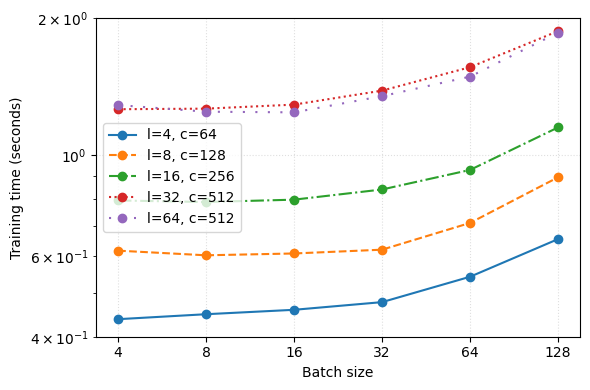

In [11]:
import matplotlib.pyplot as plt
import itertools

# Define the batch sizes used in the experiments
batch_sizes = [4, 8, 16, 32, 64, 128]
batch_labels = [str(bs) for bs in batch_sizes]

fig, ax = plt.subplots(figsize=(6, 4))
linestyles = ['-', '--', '-.', ':', (0, (1, 5))]
linecycle = itertools.cycle(linestyles)

for name, entry in logs_cpu.items():
    times = entry.get('times', [])
    if not times:
        continue
    bs_labels = batch_labels[: len(times)]
    cfg = entry.get('config', {})
    latent_dim = cfg.get('latent_dim', 'N/A')
    cmax = cfg.get('cmax', 'N/A')
    label = f"l={latent_dim}, c={cmax}"
    ax.plot(bs_labels, times, linestyle=next(linecycle), marker='o', label=label)

ax.set_xlabel('Batch size')
ax.set_ylabel('Training time (seconds)')
ax.set_ylim(0.4, 2)
ax.set_yscale('log')
ax.grid(True, linestyle=':', alpha=0.4)
ax.legend()


plt.tight_layout()

plt.show()